# Week 8 Lecture 6: Visualizing Geodata

Why Geodata visulaization in Political Science? Visualizing geodata helps us understand spatial distribution of political data of interest, for example: the economy, votes, protests, crime and conflicts.

## The case for this lecture: V-dem and UCDP Conflict data

* V-Dem: https://www.v-dem.net/
* UCDP Conflict data: https://ucdp.uu.se/

"The Uppsala Conflict Data Program (UCDP) is the world’s main provider of data on organized violence and the oldest ongoing data collection project for civil war, with a history of almost 40 years. Its definition of armed conflict has become the global standard of how conflicts are systematically defined and studied."

We have introduced the V-Dem data many times. But the UCDP Conflict Data is new. It is also a visualization, but a different kind: Geodata. It shows where the conflicts happened in the world using a map. With some customizations, it also shows the magnitude of it, such as causalities, and the types of conflicts, such as inter-state wars, intra-state rebellion, etc.

We will try to construct some similar graphs that convey the information in this lecture.


**Table of contents**

1. Draw an empty world map

2. Draw a world map of "wealth and health", i.e., Choropleth

3. Visualize Global Distribution of Conflicts

4. Loogistics


**The tool: Geopandas library**

* “GeoPandas is an open source project to add support for geographic data to pandas objects.”
* Documentation available at https://geopandas.org/en/latest/index.html


**Mapping geodata visualization to the data science workflow**

As always, we think about the workflow that is universal to all data scicence project.

* Data Input, including:

  “Map”

  Data with geo-referenced named locations (e.g., countries, cities, counties)

  Data with geo-referenced points

* Data processing
  Merge data with the map
  Aggregate

* Data Output: Save and export the plot

**Overview and summary**

Again, this is a very technical lecture. Try to memorize the following concepts and commands will help you quickly get the gist of his lecture.

- Importing Geopandas and related libraries
  
- Load map file: `gpd.read_file()`
  
- Data type of Geometry
  
- Customizations: `color`, `edgecolr`, `figsize`, `.set_axis_off()`, `legend=True`, `legend_kwd{'shrink':0.5, 'orientation':'horizontal'}`, `cmap`, and `marker`

- Merging map with data: `df.merge()`

- Preparing geodataframe

Also try to remember the codes that generate a very well-plotted graph, that was my way of quickly mastering the syntax and available options to customize.

## 1. Draw an empty World Map

**Maps**

Maps often show up as "colored shaped" in our mind. For Python and more generally modern computers, it is a bit different. **Maps in Python are just a bunch of points that marks the boundaies of geographic unites of interest. The points are connected by straight lines.**

Let's get an example to see it clearer. Please go and download a map readable by Python. Use the Admin 0 - Countries point-of-views, China POV:
https://www.naturalearthdata.com/downloads/10m-cultural-vectors/

You can see that the information of the map is stored in multiple files, with the .shp file is the most important, which we will use for the rest of this lecture.

**Importing Geopandas**

To use geopandas, import the library first. We usually shorten its name as gpd. We also normally import pandas, seaborn, and matplotlib. When you are more familiar with Python and the data science workflow, you would normally know which libraries to import even before you use their functions. And this will become a muscle memory in the future.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**A note on the use of map files**

Import the map and store it as "world". **Note that Geopandas can also read the map folder, without being zipped.**

If you use Safari on Mac, it will automatically unzip upon Download. Don’t re-compress it  -- there will be error reading a folder re-compressed folder by Mac, because Mac create an additional layer for the compressed folder.

To stop Safari from automatically unzipping, after opening a Safari window, you can press command+comma to pull out the settings menu, then, you uncheck the option of "Open safe files after downloading".


In [ ]:
world = gpd.read_file("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week7/demo/data_raw/ne_10m_admin_0_countries_chn.zip")

In [ ]:
# If you unzip the folder, you can also read the map from the unzipped folder.
world = gpd.read_file("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week7/demo/data_raw/ne_10m_admin_0_countries_chn")

<Axes: >

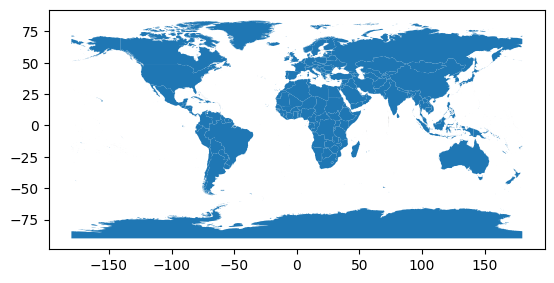

In [ ]:
world.plot()

In [ ]:
world

,ADM0_A3_CN,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,IDN,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,MYS,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,CHL,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,BOL,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,PER,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,CSI,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,...,None,None,None,None,None,None,None,None,None,"POLYGON ((154.39129 -21.03004, 154.38852 -21.0..."
242,CLP,Admin-0 country,6,5,France,FR1,1,2,Dependency,1,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-109.21203 10.30268, -109.21036 10.2..."
243,MAC,Admin-0 country,0,4,China,CH1,1,2,Country,1,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
244,ATC,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,...,None,None,None,None,None,None,None,None,None,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."


If you look at the world object, you see that it is simply a table, the kind that we see in previous weeks. So how is the table turned into a map?

In [ ]:
world.geometry

,geometry
0,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...
241,"POLYGON ((154.39129 -21.03004, 154.38852 -21.0..."
242,"POLYGON ((-109.21203 10.30268, -109.21036 10.2..."
243,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
244,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."


So, this is it. There is one column in this table that stores all the geometric information of the map. You see several types of geometry, including Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, and GeometryCollection. The last kind is a collection of any previous kinds.


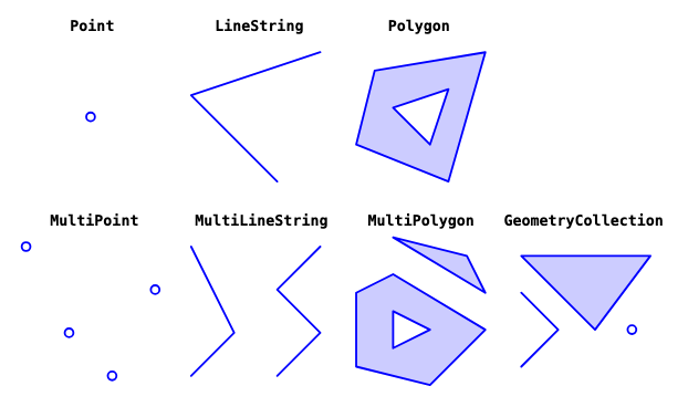

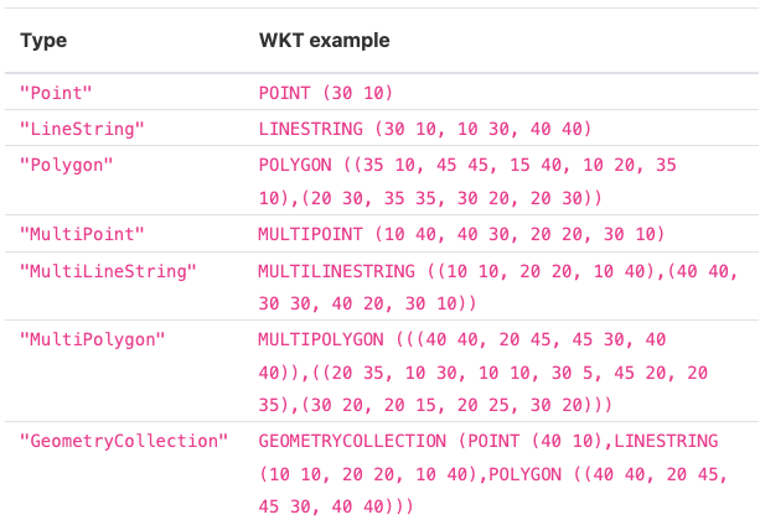

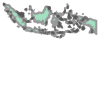

In [ ]:
world.geometry[0]

**Customization: Color**

There are two types of color you can customize: The color that fills in the polygon, and the color that marks the boundaries.

<Axes: >

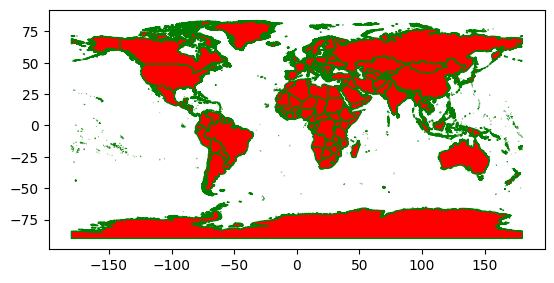

In [ ]:
world.plot(color = "red", edgecolor = "green")

**Customization: size**

Since the maps are just a bunch of polygons, it gets clearer as the figure size increases, as more details are drawn by Python. But you don't want to make it too big, sometimgs Python will cut off figures that are too big. To specify the size of a map, use the argument of `figsize`.

<Axes: >

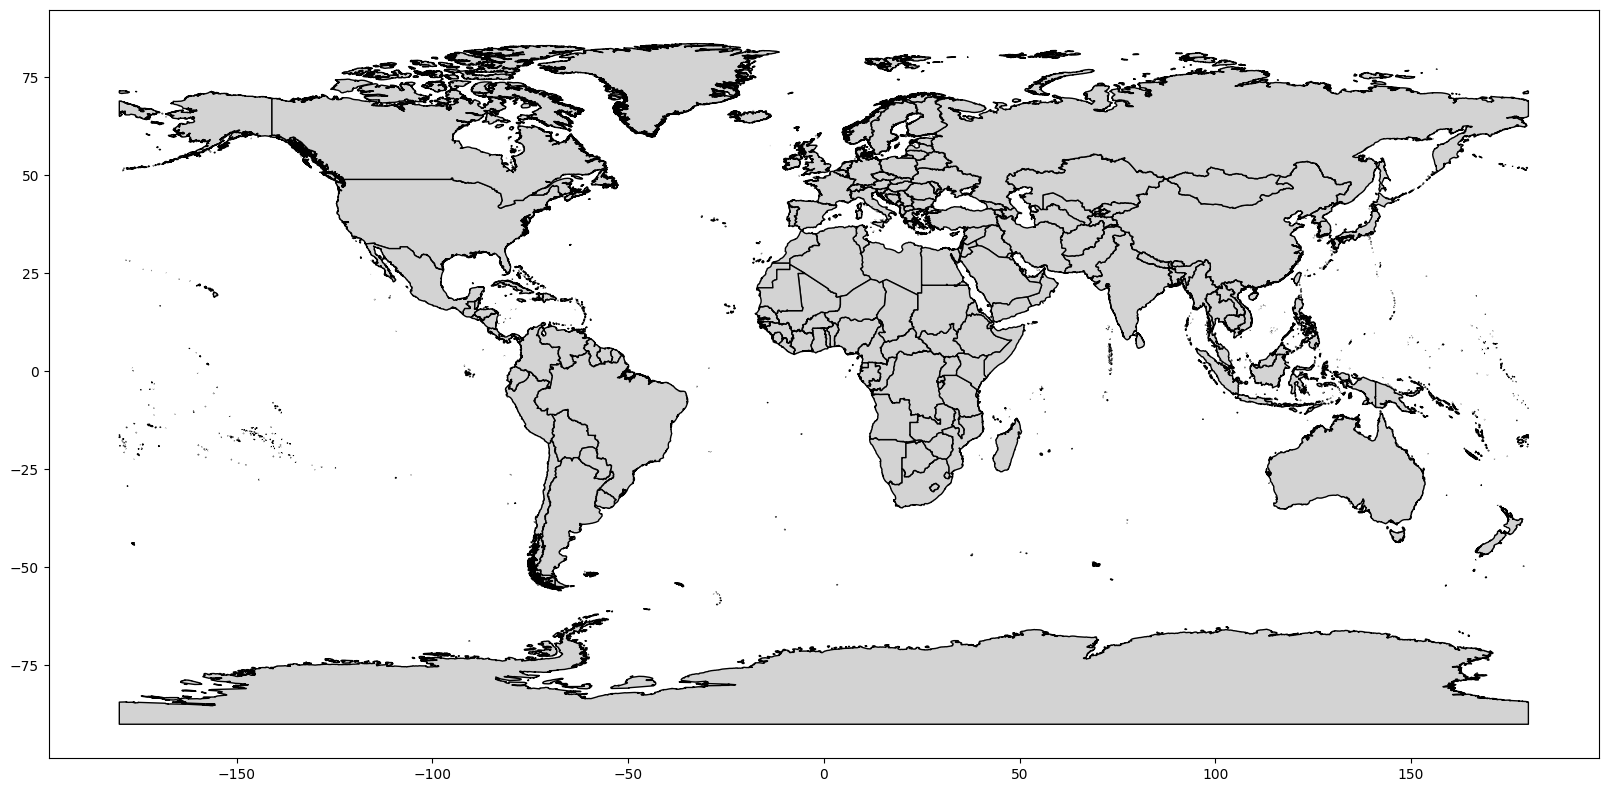

In [ ]:
world.plot(color = "lightgray", edgecolor = "black", figsize = (20, 10))

**Customization: Axis Off**

For a world map in our mind, there should be no axes. We can use the method of `.set_axis_off()` to remove them. But under the hood, Python still refers to the axes to draw out the polygons.

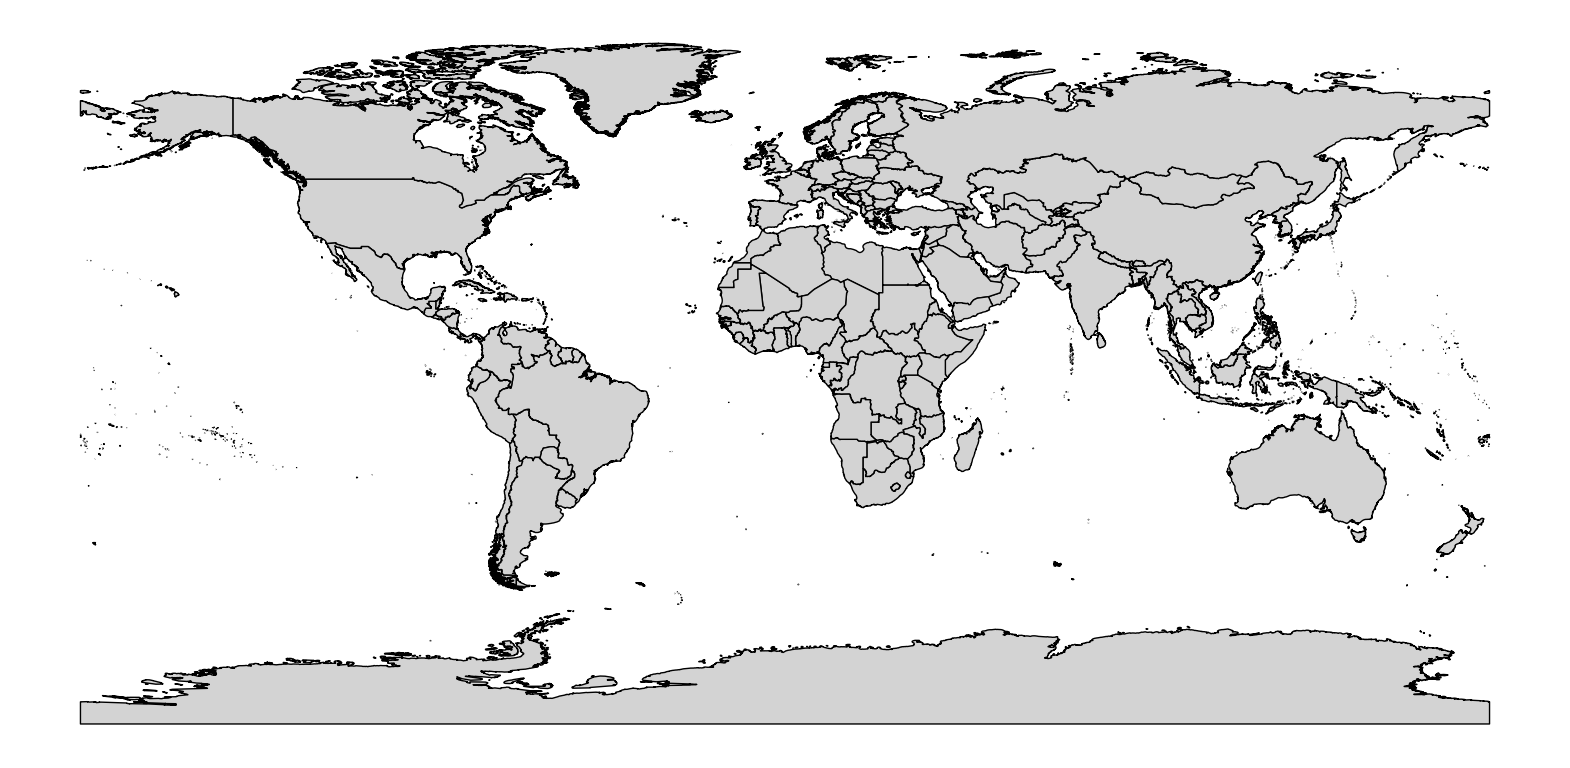

In [ ]:
world.plot(color = "lightgray", edgecolor = "black", figsize = (20, 10)).set_axis_off()

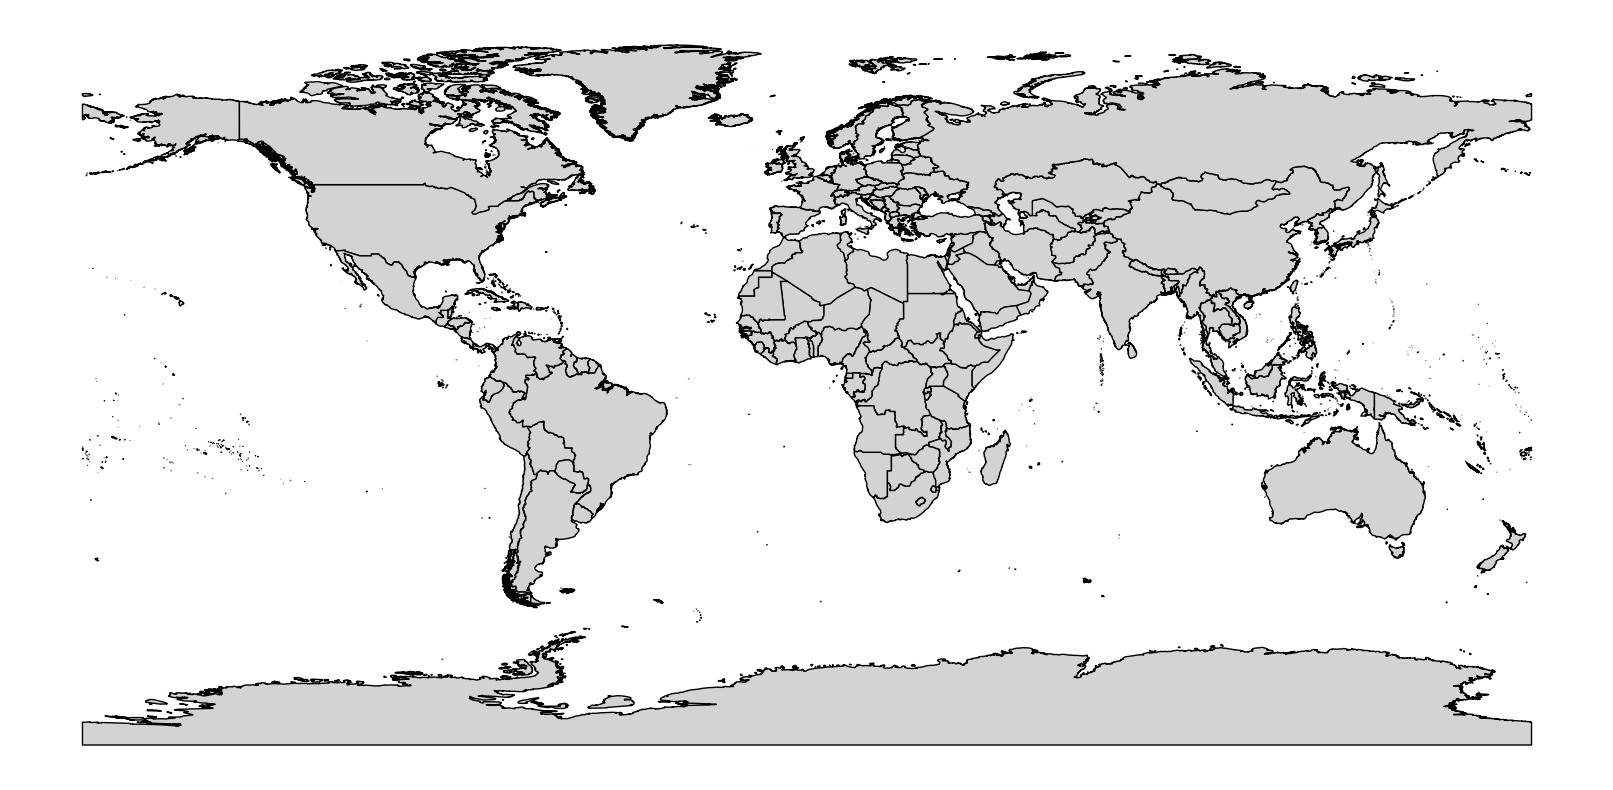

In [ ]:
world.plot(color = "lightgray", edgecolor = "black", figsize = (30, 10)).set_axis_off()

**Practice**

* Can you add a title and remove the axes labels?

* What are the other columns in the “world” GeoPandas dataframe? What do they mean?

* Play with figsize. Is the size perfectly in line with your setting? If not, why? Hint: Check the “aspect” argument in the documentation: https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html


## 2. Draw a World Map of “Wealth and Health” (Choropleth)

What is a choropleth?

"A choropleth map is a type of statistical thematic map that uses pseudocolor, meaning color corresponding with an aggregate summary of a geographic characteristic within spatial enumeration units, such as population density or per-capita income."

This touches some further steps of visualizing geodata. we will work with data with geo-referenced named locations by merging wealth and health data with the map.

Data with "geo-referenced named locations" refers to datasets whose data points are identified with geo-referenced named locations, such as dataset of GDP per capita across countries, or dataset of life expectancy across countries

Other examples: All kinds of data aggregated at the level of continents/ countries/ states/ provinces/ cities/ township/ zip code, etc


Remember that we made the following figure last time? What if we want to know the grographic distribution?

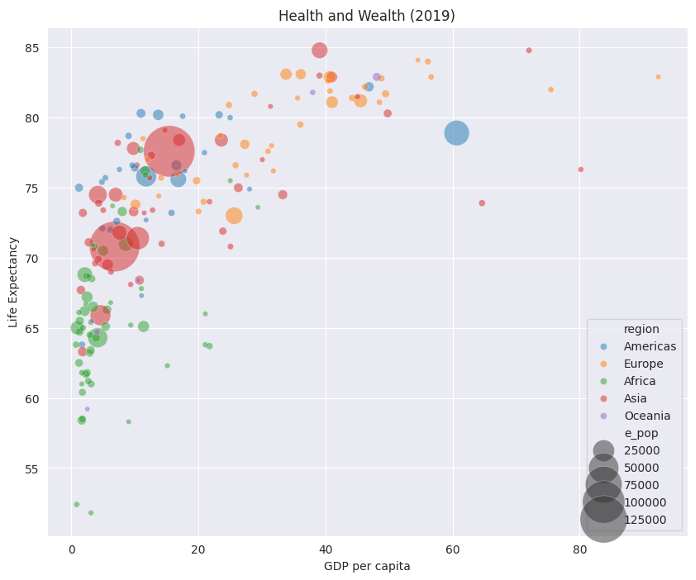

Let's load the V-Dem data first, recycling our code from last lecture.

In [ ]:
df_vdem = pd.read_csv("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week4/demo/data/V-Dem-CY-Full+Others-v14.csv")

<ipython-input-16-0637a8551fd0>:1: DtypeWarning: Columns (364,365,366,399,415,804,836,837,924,1240,1257,1486,3094,3168,3169,3341,3342,3344,3345,3347,3350,3352) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vdem = pd.read_csv("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week4/demo/data/V-Dem-CY-Full+Others-v14.csv")


In [ ]:
df_vdem_s = df_vdem.loc[df_vdem.year == 2019, :]

In [ ]:
df_vdem_s.shape

(179, 4607)

In [ ]:
df_vdem_s

,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,e_mipopula,e_miurbani,e_pefeliex,e_wb_pop,e_pechmor,e_miinteco,e_civil_war,e_miinterc,e_pt_coup,e_pt_coup_attempts
230,Mexico,MEX,3,2019,2019-12-31,0,1,United Mexican States,1789,2023,...,NaN,NaN,NaN,127575529.0,12.50,NaN,NaN,NaN,0.0,0.0
354,Suriname,SUR,4,2019,2019-12-31,0,0,Republic of Suriname [independent state],1900,2023,...,NaN,NaN,NaN,581363.0,18.40,NaN,NaN,NaN,0.0,0.0
589,Sweden,SWE,5,2019,2019-12-31,0,1,Kingdom of Sweden,1789,2023,...,NaN,NaN,NaN,10278887.0,2.62,NaN,NaN,NaN,0.0,0.0
815,Switzerland,CHE,6,2019,2019-12-31,0,1,Swiss Confederation,1798,2023,...,NaN,NaN,NaN,8575280.0,4.01,NaN,NaN,NaN,0.0,0.0
937,Ghana,GHA,7,2019,2019-12-31,0,0,Republic of Ghana,1902,2023,...,NaN,NaN,NaN,30417858.0,46.20,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25719,Solomon Islands,SLB,203,2019,2019-12-31,0,0,Solomon Islands [independent state],1900,2023,...,NaN,NaN,NaN,669821.0,19.50,NaN,NaN,NaN,0.0,0.0
25843,Vanuatu,VUT,206,2019,2019-12-31,0,0,Republic of Vanuatu [independent state],1900,2023,...,NaN,NaN,NaN,299882.0,25.70,NaN,NaN,NaN,0.0,0.0
25896,United Arab Emirates,ARE,207,2019,2019-12-31,0,0,United Arab Emirates [Independent state formed...,1971,2023,...,NaN,NaN,NaN,9770526.0,7.37,NaN,NaN,NaN,0.0,0.0
26162,Hungary,HUN,210,2019,2019-12-31,0,1,Hungary,1789,2023,...,NaN,NaN,NaN,9771141.0,4.12,NaN,NaN,NaN,0.0,0.0


**Important: Merge data with map**

This touches the core of geodata visualization. The map files contain standardized codes (e.g., CHN for China) or names for each country. The V-Dem data also includes these variables. We join the two datasets using the country code, because there might be some variations in country names, such as United States of America vs. United States.

Therefore, in the merged data, we have countries' geographic informarion represented in various point, lines, and polygons, and wealth/health data. This is what we need to visualize the geographic distribution of our variables of interest.

The complete syntax for the following piece of code is:
```
DataFrame.merge(right, how='left', on=None, left_on=None, right_on=None)
```
Please go to https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html for more detailed information on the syntax.

By the following piece of code, we are joining the world_vdem (the "left" dataset), and the world map (the right dataset), preserving all entries in the left dataset (```how="left"```), and using columns names of "ADM0_A3_CN" and "country_text_id" (```left_on = "ADM0_A3_CN",right_on = "country_text_id"```)

In [ ]:
world_vdem = pd.merge(world, df_vdem_s,
                      left_on = "ADM0_A3_CN",
                      right_on = "country_text_id",
                      how = "left")

In [ ]:
world_vdem

,ADM0_A3_CN,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,...,e_mipopula,e_miurbani,e_pefeliex,e_wb_pop,e_pechmor,e_miinteco,e_civil_war,e_miinterc,e_pt_coup,e_pt_coup_attempts
0,IDN,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,...,NaN,NaN,NaN,270625567.0,24.10,NaN,NaN,NaN,0.0,0.0
1,MYS,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,...,NaN,NaN,NaN,31949789.0,7.58,NaN,NaN,NaN,0.0,0.0
2,CHL,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,...,NaN,NaN,NaN,18952035.0,7.03,NaN,NaN,NaN,0.0,0.0
3,BOL,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,...,NaN,NaN,NaN,11513102.0,26.10,NaN,NaN,NaN,0.0,0.0
4,PER,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,...,NaN,NaN,NaN,32510462.0,13.90,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,CSI,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242,CLP,Admin-0 country,6,5,France,FR1,1,2,Dependency,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,MAC,Admin-0 country,0,4,China,CH1,1,2,Country,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,ATC,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Note: You should fully understand the following code snippet by now.

<Axes: >

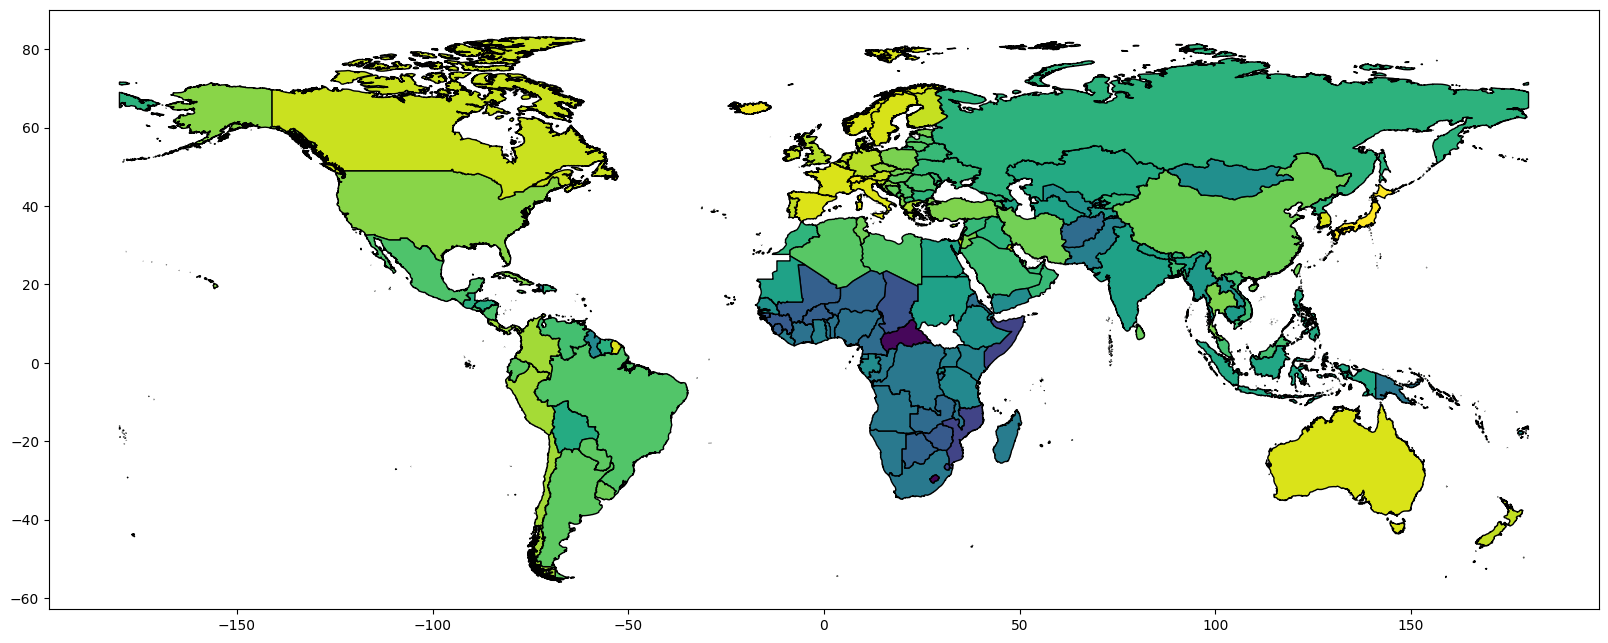

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
               figsize = (20, 10))

**Customizations: Adding Legends**

This can be important for readers of your plots to know which color indicates higher value.


<Axes: >

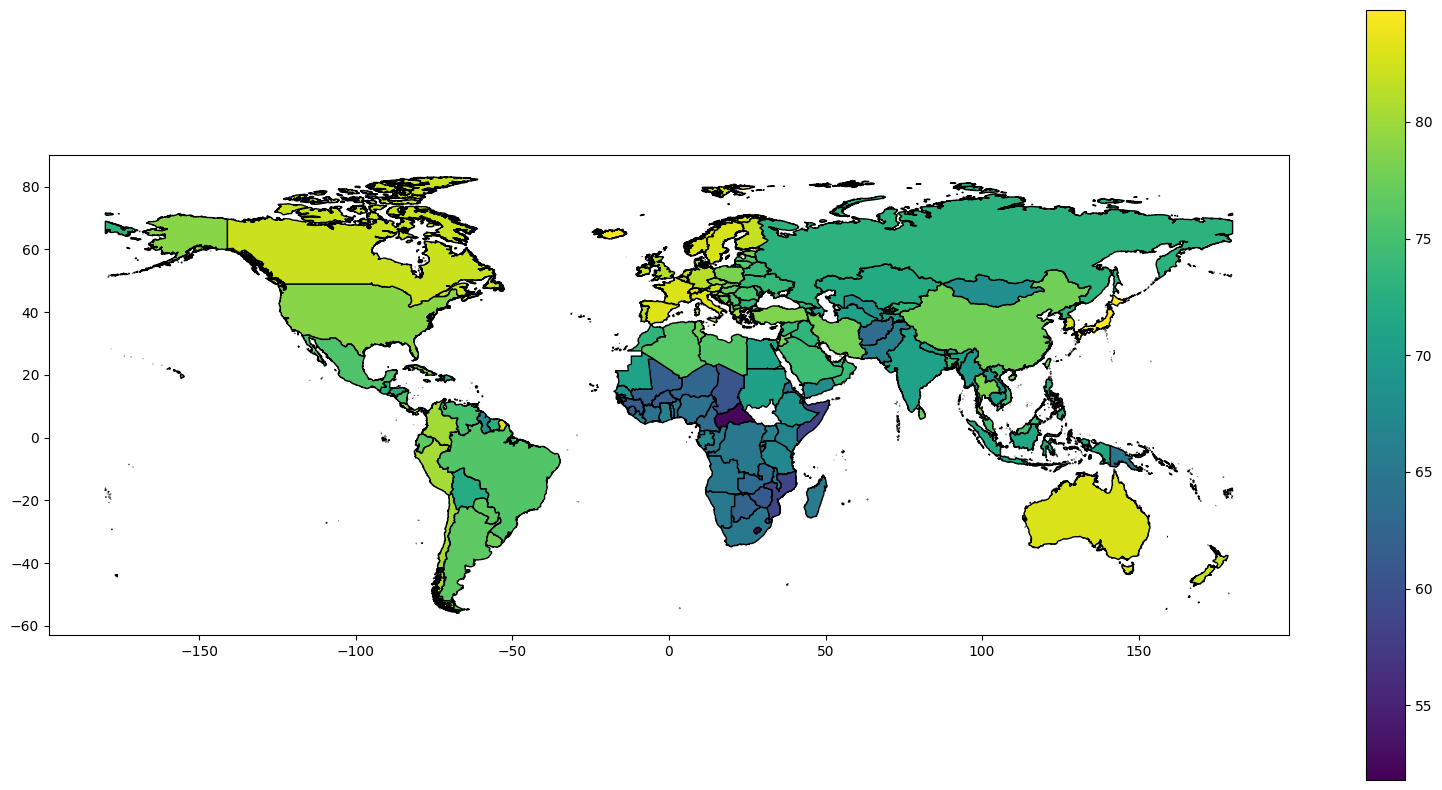

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
               figsize = (20, 10), legend = True)

**Customization: Resizing Legend**

The legend of the last plot was clearly too big. Even higher than the whole plot. We want that to be smaller and a bit more porpotional to the whole plot. Use `legend_kwds = {'shrink': 0.5}` to shrink that.

<Axes: >

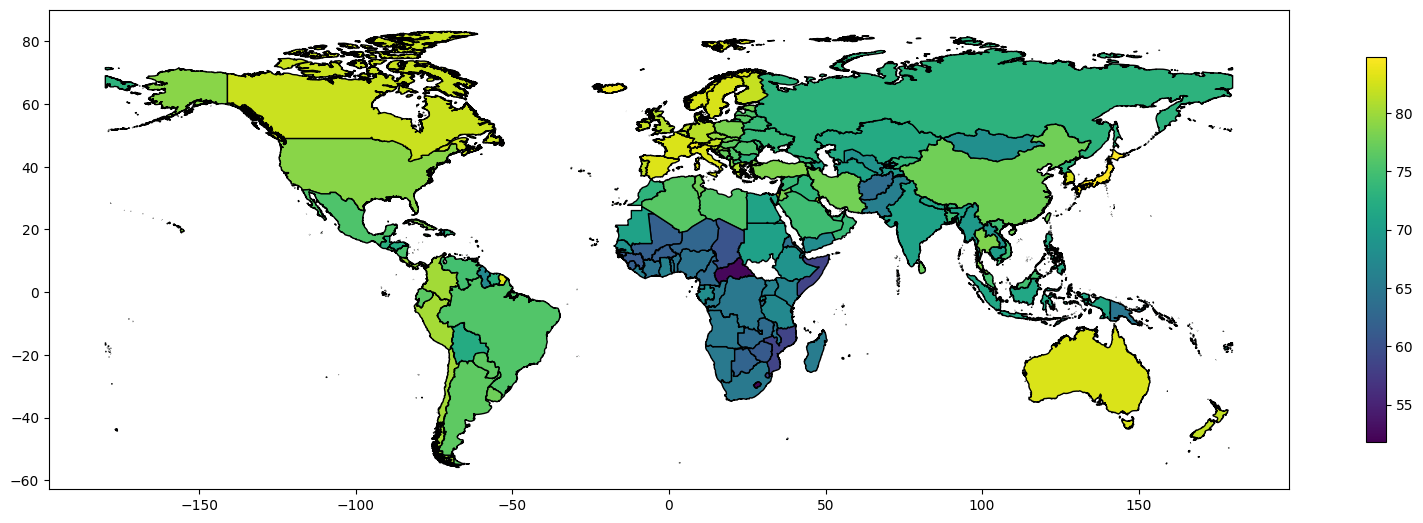

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
               figsize = (20, 10), legend = True,
                legend_kwds = {'shrink': 0.5})

**Horizontal Legend (optional)**



<Axes: >

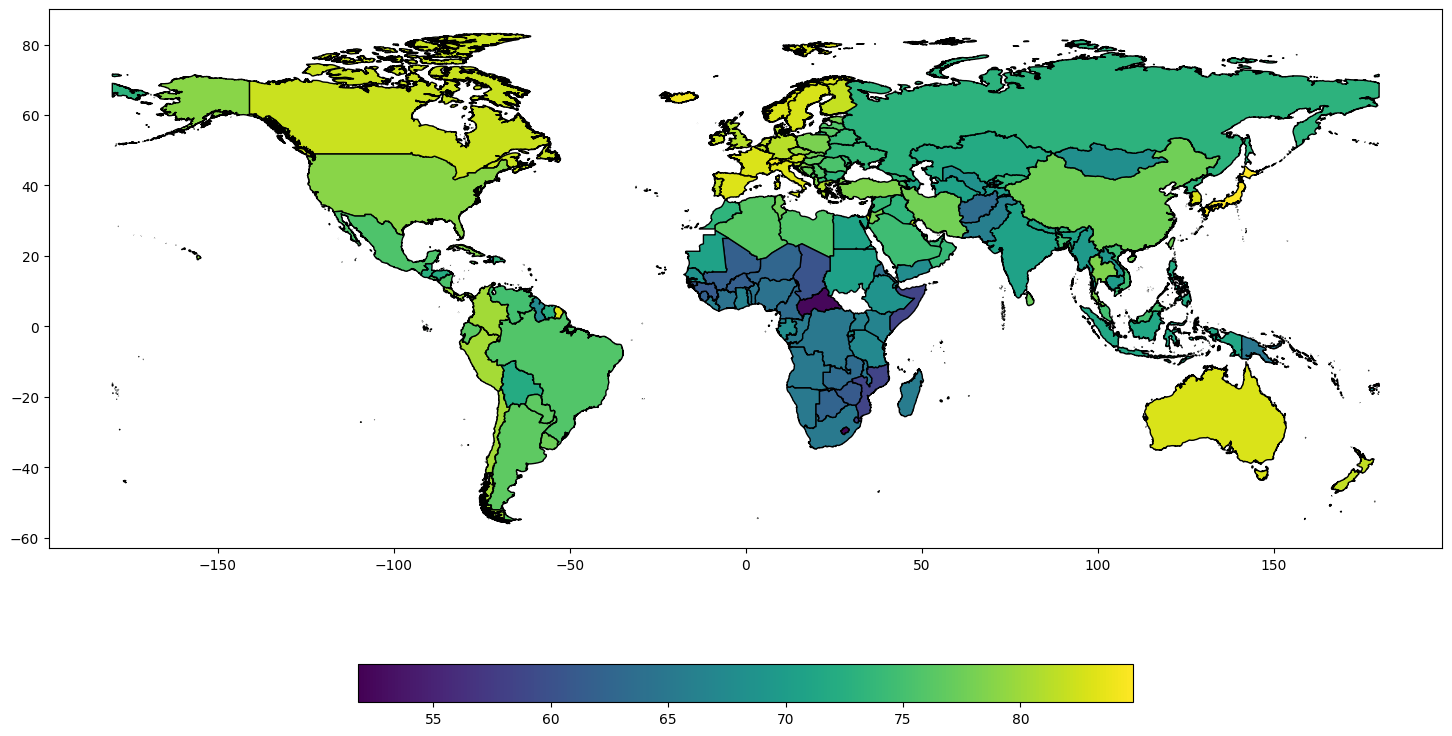

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
                figsize = (20, 10), legend = True,
                legend_kwds = {'shrink': 0.5, "orientation": "horizontal"})

**Change color palette**

The `cmap` part customizes the color palette of the plot. It stands for Yellow/Orange/Red (not Yellow or Red). You can find some other color schemes here: https://matplotlib.org/stable/users/explain/colors/colormaps.html

You can even create your own color palette if you like: https://matplotlib.org/stable/gallery/color/custom_cmap.html

<Axes: >

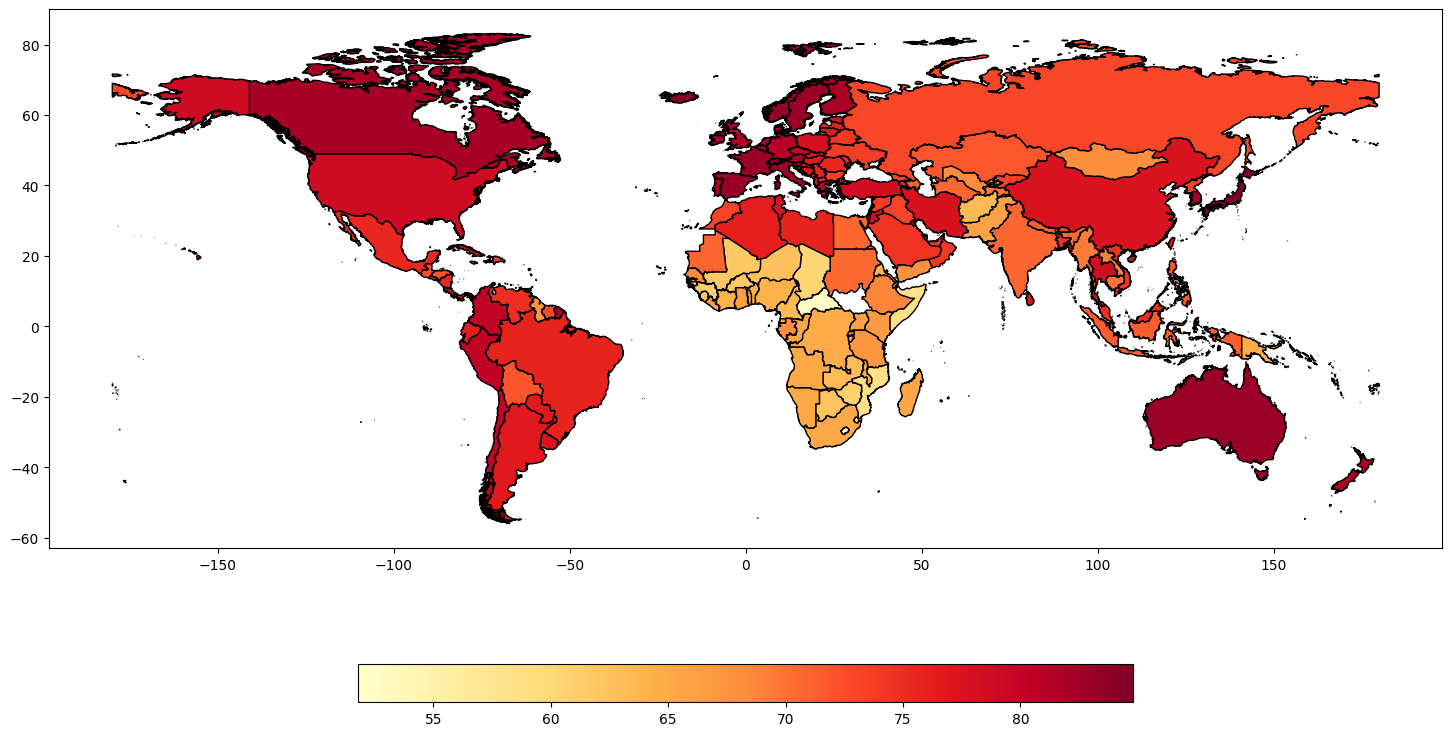

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
                figsize = (20, 10), legend = True,
                legend_kwds = {'shrink': 0.5, "orientation": "horizontal"},
                cmap = "YlOrRd")

**Remove axes**

Like we talked before, this makes it more like a normal world map, although Python still uses the axes to locate each polygon under the hood.

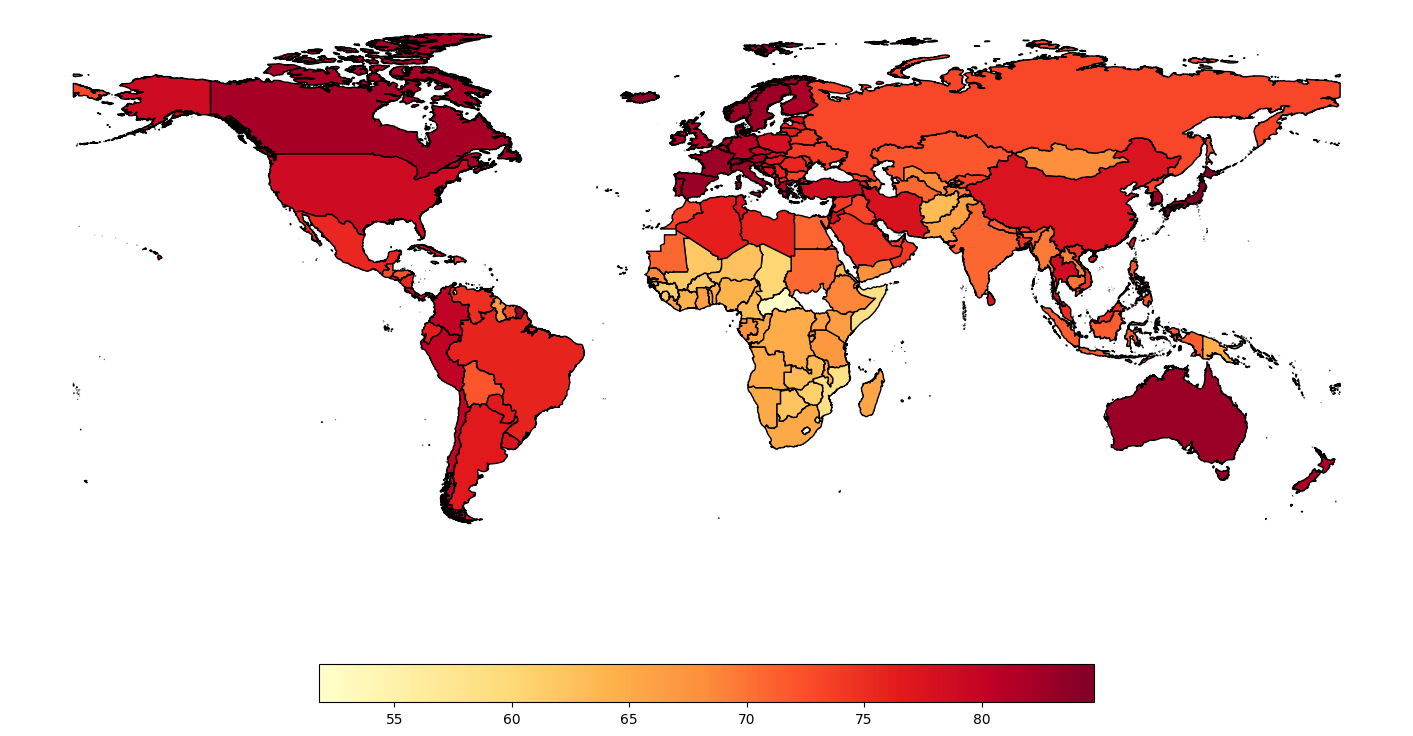

In [ ]:
world_vdem.plot(column = "e_pelifeex", edgecolor = "black",
                figsize = (20, 10), legend = True,
                legend_kwds = {'shrink': 0.5, "orientation": "horizontal"},
                cmap = "YlOrRd").set_axis_off()

**Try it yourself**

* Choose a color palette you like

* Remove the axes texts and labels of ALL maps Hint: “.set_axis_off()”

* Visualize the geo-distribution of the “wealth” indicator: GDP per capita

* Check the map: Find some white area? Why? Answer: missing data


## 3. Visualize Global Distribution of Conflicts (Bubble Map)

Now we are dealing with "data with geo-referenced points", which still needs to merge data with the map.

We use the UCDP Georeferenced Event Data. Please download the UCDP GED dataset: https://ucdp.uu.se/downloads/ged/ged241-csv.zip
And upload to your Google Drive project folder.

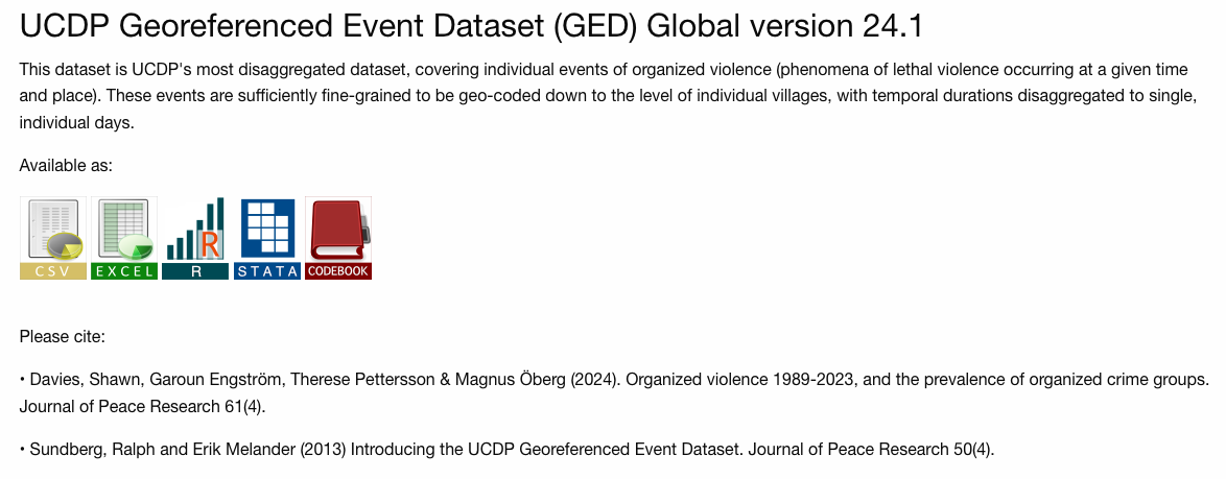

In [ ]:
df_ucdp = pd.read_csv("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week7/demo_prep/data_raw/UCDP/ged241-csv.zip")

<ipython-input-31-a54b143c7b5b>:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ucdp = pd.read_csv("/content/drive/MyDrive/POLI3148_2024Fall/Exercise/Week7/demo_prep/data_raw/UCDP/ged241-csv.zip")


In [ ]:
df_ucdp.shape

(349733, 49)

In [ ]:
df_ucdp.loc[1, :]

,1
id,412700
relid,IRQ-2021-1-524-145
year,2021
active_year,1
code_status,Clear
type_of_violence,1
conflict_dset_id,259
conflict_new_id,259
conflict_name,Iraq: Government
dyad_dset_id,524


As a recommended step, use this command to get a sense of the data structure:

In [ ]:
df_ucdp.loc[1, :].to_dict()

{'id': 412700,
 'relid': 'IRQ-2021-1-524-145',
 'year': 2021,
 'active_year': 1,
 'code_status': 'Clear',
 'type_of_violence': 1,
 'conflict_dset_id': 259,
 'conflict_new_id': 259,
 'conflict_name': 'Iraq: Government',
 'dyad_dset_id': 524,
 'dyad_new_id': 524,
 'dyad_name': 'Government of Iraq - IS',
 'side_a_dset_id': 116,
 'side_a_new_id': 116,
 'side_a': 'Government of Iraq',
 'side_b_dset_id': 234,
 'side_b_new_id': 234,
 'side_b': 'IS',
 'number_of_sources': 15,
 'source_article': '"BBC News,2021-08-26,Explosion at Kabul airport";"ShamshadNews on Twitter,2021-08-26,At least 11 people killed in explosion outside Kabul airport: Sources";"Xinhua News Agency,2021-08-30,Xinhua Headlines: Afghan airport bombing survivors say some civilians killed by U.S. bullets";"Agence France Presse,2021-08-27,Only one suicide bomber in Kabul attack: Pentagon";"Reuters News,2021-08-27,UPDATE 13-Pentagon bracing for more attacks after troops killed at Kabul airport";"Xinhua News Agency,2021-08-27,Roun

The geographic information for this dataset is stored in geom_wkt. It contains longitude and latitude of the events.

In [ ]:
df_ucdp.geom_wkt

,geom_wkt
0,POINT (69.162796 34.531094)
1,POINT (69.2172222 34.5644444)
2,POINT (70.45575 34.428844)
3,POINT (69.162796 34.531094)
4,POINT (70.41667 34.33333)
...,...
349728,POINT (32.5 -20.5)
349729,POINT (32.5 -19)
349730,POINT (32.833333 -18)
349731,POINT (32.5 -19)


In [ ]:
gpd.GeoSeries.from_wkt(df_ucdp.geom_wkt)
# Parse the geo-information with the GeoPandas Library, then create a new column named “geometry” to store the parsed information
# Check its data type!
# Warning: difficult part. Re-read to make sure you understand what it does


,0
0,POINT (69.1628 34.53109)
1,POINT (69.21722 34.56444)
2,POINT (70.45575 34.42884)
3,POINT (69.1628 34.53109)
4,POINT (70.41667 34.33333)
...,...
349728,POINT (32.5 -20.5)
349729,POINT (32.5 -19)
349730,POINT (32.83333 -18)
349731,POINT (32.5 -19)


In [ ]:
df_ucdp.loc[:, 'geometry'] = gpd.GeoSeries.from_wkt(df_ucdp.geom_wkt)

Alternatively, you can also use this method:

```
df_ucdp.loc[:, 'geometry'] = gpd.points_from_xy(df_ucdp.longitude, df_ucdp.latitude)
```

It uses numeric longitude and latitude columns to create a geo-location indicator.

Note: Longitude should come first, then latitude.
Try what you get if you flip the two… I made this mistake before. You can make this mistake when you work with data from a single country/ continent.


**Prepare the Geo-referenced data**

What’s this? (Warning: Difficult part. Please re-read to make sure you understand)

* df_ucdp is a Pandas dataframe, NOT a GeoPandas dataframe. The step convert it to a GeoPandas Dataframe
Arguments

* crs: Controls the projection system (see Kaggle reading). We use the same system as the map

* geometry: Tell Python what makes the “geometry” column


In [ ]:
df_ucdp_geo = gpd.GeoDataFrame(df_ucdp,
                               crs = world_vdem.crs,
                               geometry = df_ucdp.geometry)

In [ ]:
df_ucdp_geo

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,geometry
0,244657,IRQ-2017-1-524-322,2017,1,Clear,1,259,259,Iraq: Government,524,...,0,4,0,2,6,6,6,645,NaN,POINT (69.1628 34.53109)
1,412700,IRQ-2021-1-524-145,2021,1,Clear,1,259,259,Iraq: Government,524,...,13,1,141,28,183,184,171,645,NaN,POINT (69.21722 34.56444)
2,413023,IRQ-2021-1-524-143,2021,1,Clear,1,259,259,Iraq: Government,524,...,0,2,0,0,2,3,0,645,NaN,POINT (70.45575 34.42884)
3,412909,IRQ-2021-1-524-144,2021,1,Clear,1,259,259,Iraq: Government,524,...,0,0,10,0,10,10,9,645,NaN,POINT (69.1628 34.53109)
4,132140,AFG-1989-1-411-2,1989,1,Clear,1,333,333,Afghanistan: Government,724,...,6,0,0,0,6,6,6,700,NaN,POINT (70.41667 34.33333)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349728,15525,MZM-1989-3-1347-4,1989,1,Clear,3,498,562,Renamo - Civilians,498,...,0,0,9,0,9,9,9,NaN,NaN,POINT (32.5 -20.5)
349729,15524,MZM-1989-3-1347-16,1989,1,Clear,3,498,562,Renamo - Civilians,498,...,0,0,9,0,9,9,9,NaN,NaN,POINT (32.5 -19)
349730,15245,MZM-1990-3-1347-18,1990,1,Clear,3,498,562,Renamo - Civilians,498,...,0,0,7,0,7,7,7,NaN,NaN,POINT (32.83333 -18)
349731,15516,MZM-1990-3-1347-28,1990,1,Clear,3,498,562,Renamo - Civilians,498,...,0,0,1,0,1,1,1,NaN,NaN,POINT (32.5 -19)


After that, we can plot this map. We make a figure with the two layers.

* The 1st layer is the world map, stored temporarily in an object named ax

* The 2nd layer include all the points indicating conflict incidents. Painted on top of the world map


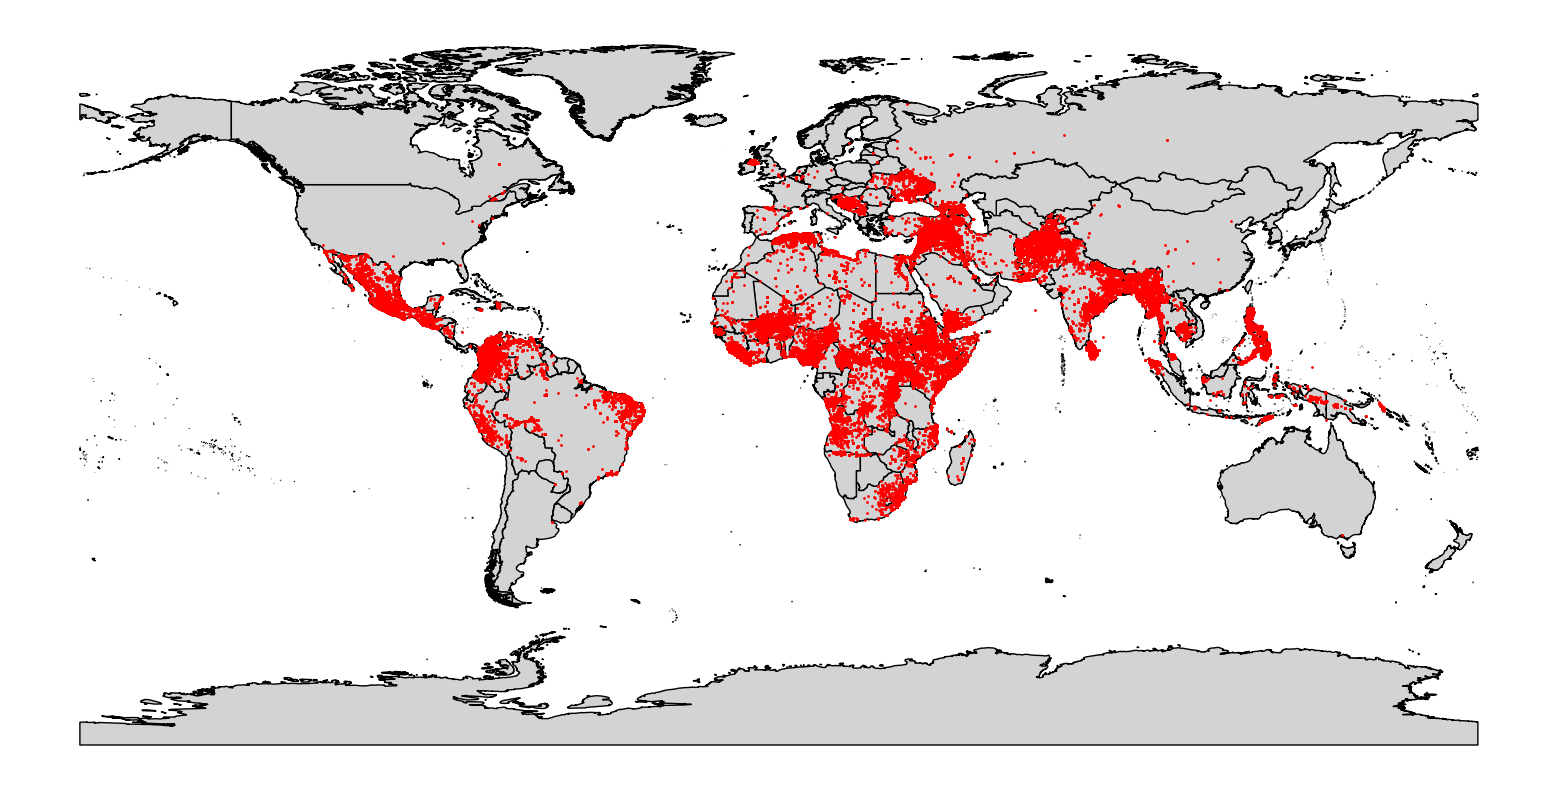

In [ ]:
ax = world_vdem.plot(color = "lightgray", edgecolor = "black",
                     figsize = (20, 10))
df_ucdp_geo.plot(ax = ax, marker = 'o',
                 color = 'red', markersize = 1).set_axis_off()

**Set Transparency**

Sometimes, points overlap with each other, which makes the plot less informative. Setting alpha makes it easier for us to know where do more conflicts happen.

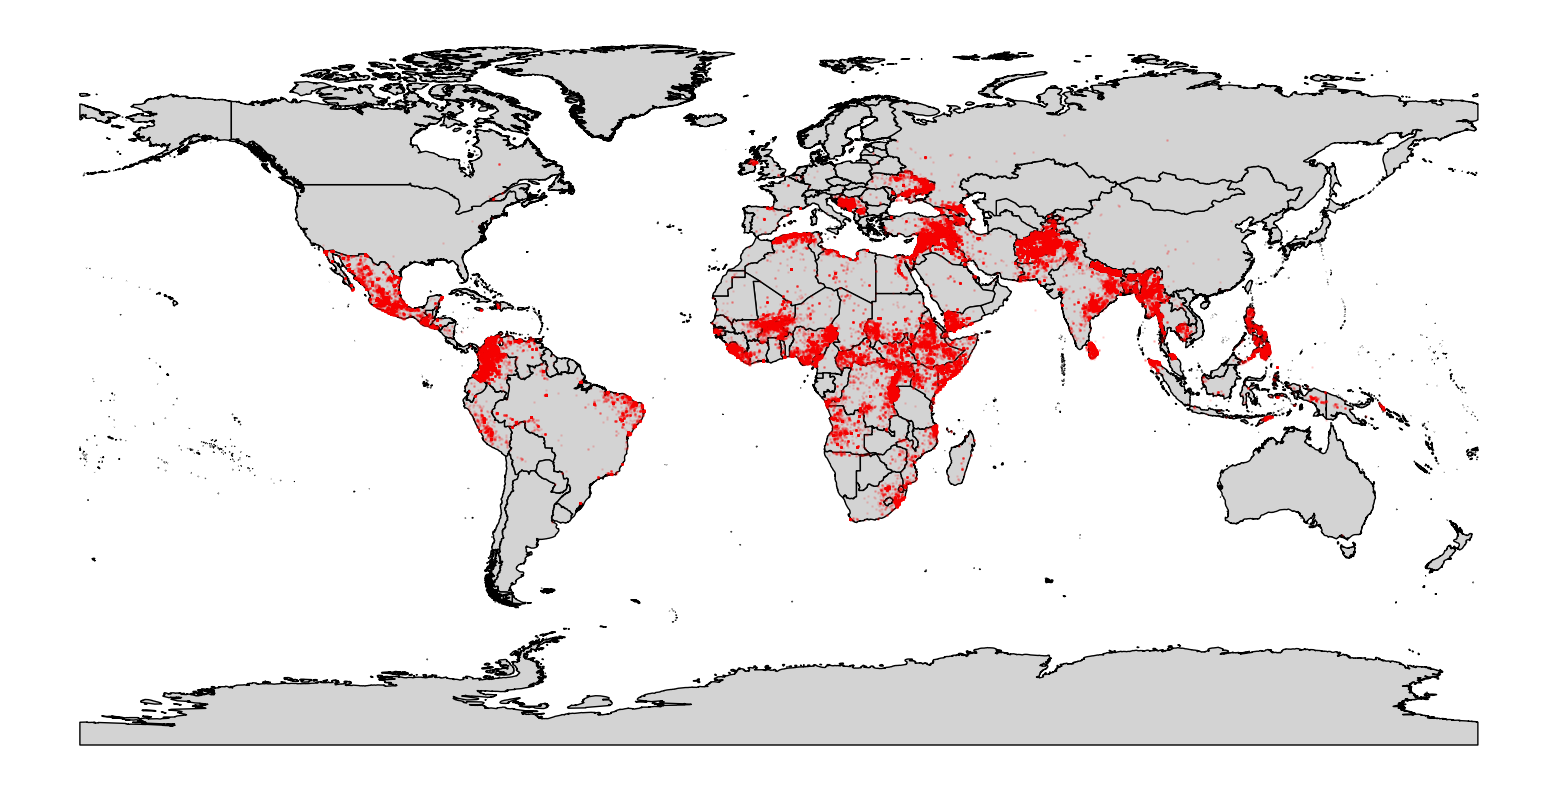

In [ ]:
ax = world_vdem.plot(color = "lightgray", edgecolor = "black",
                     figsize = (20, 10))
df_ucdp_geo.plot(ax = ax, marker = 'o',
                 color = 'red', markersize = 1,
                 alpha = 0.1).set_axis_off()

**Adding another variable with the size of points**

Let sizes indicate the number of deaths of civilians.

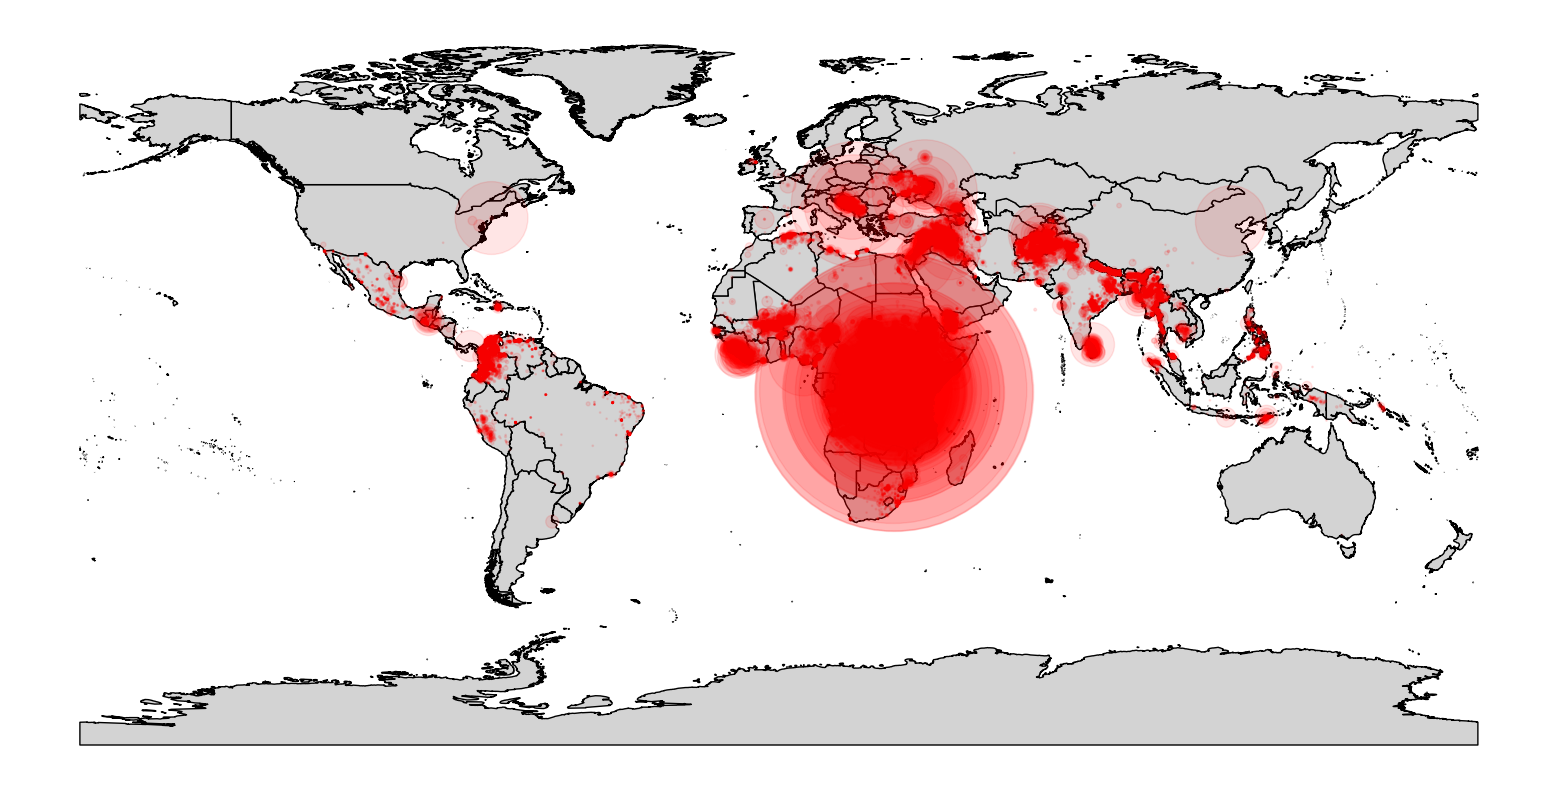

In [ ]:
ax = world_vdem.plot(color = "lightgray", edgecolor = "black",
                     figsize = (20, 10))
df_ucdp_geo.plot(ax = ax, marker = 'o',
                 color = 'red', markersize = 'deaths_civilians',
                 alpha = 0.1).set_axis_off()

**Try it yourself**

* Add legend to the last figure (think: why do we want a legend?)

* Change the colors to make the maps prettier

* Resize the bubbles to make them more informative: Divide by a constant? Square-root transformation?

* Add titles to the maps

* Visualize different variables related to the conflict


## Summary

**Two types of data, two types of basic geo visualization**

* Data associated with geo-referenced named locations -- Choropleths

* Data associated with geo-referenced points -- Bubble maps

The two basic types of geo data visualization. They are helpful because:

* Straightforward from the data, no complicated data wrangling

* Wide range of application: Descriptive statistics, Exploratory analysis, Communicating output to the public

**Dont' get distracted and intimidated**

* Geodata visualization is a BIG industry

* Many tools are designed by geographers, environmental scientists etc.

* Many are legitimately complicated because of the complexity of application in these fields where the tools are developed

* However, our application, even for many advanced research, only need a tiny portion of them

* Don’t waste time to learn things you don’t need (or feeling bad about not knowing the complicated things). Just focus on what you need.

**Additional resources**

* ACLED: https://acleddata.com/ (more diverse types of conflicts)
* GDELT: https://www.gdeltproject.org/ (comprehensive, but more “noisy”)

When you use these event data, read the codebook carefully to understand how these events are defined.

* GeoPandas documentation
https://geopandas.org/en/latest/index.html

Note: GeoPandas has evolved. Many resources you find online can be obsolete. Don’t be surprised if they don’t work because of recent updates. Generative AIs, typically trained with older data, can make the same mistakes.
Whenever you are unsure, consult with the official documentation (the link above).



## 4. Logistics

There is NO in-calss exercise for this lecture. But do practice the skills of drawing maps. It will be included in assignments and final projects.